In [4]:
import pandas as pd
df = pd.read_csv('worlds_deadliest_animals.csv')
df.head()

,Animal,Animal_Type,Number of humans killed per year,Estimate_Qualifier
0,Mosquitoes,Insect,760000,NaN
1,Humans,Mammal,600000,NaN
2,Snakes,Reptile,100000,NaN
3,Dogs,Mammal,40000,NaN
4,Freshwater snails,Mollusc,14000,NaN


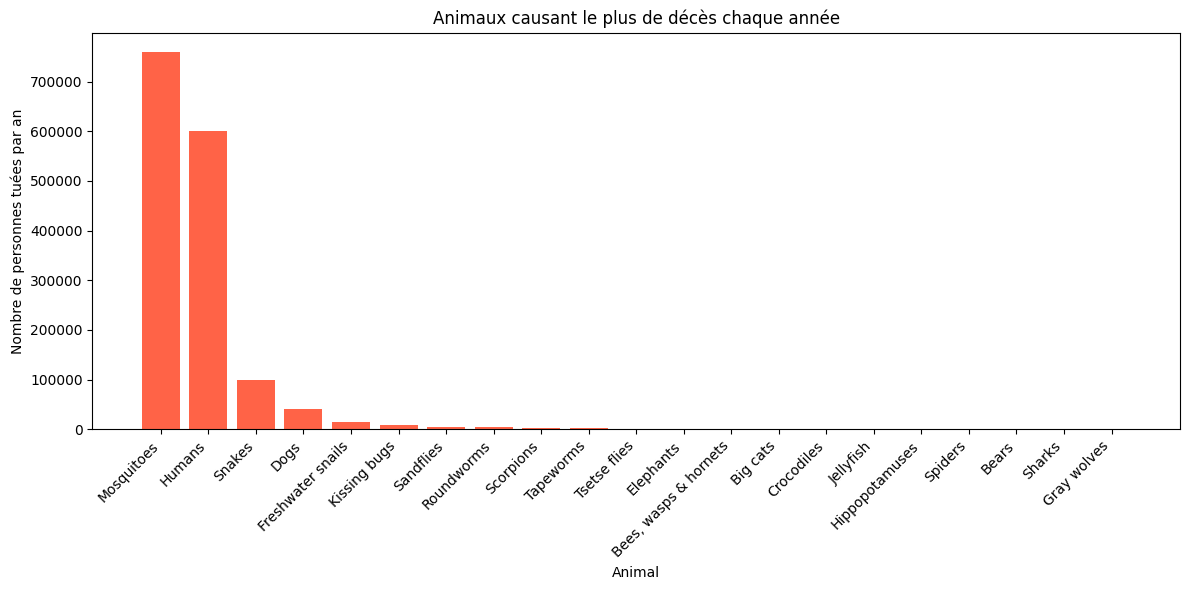

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

plt.bar(
    df["Animal"],
    df["Number of humans killed per year"],
    color="tomato"
)

plt.xlabel("Animal")
plt.ylabel("Nombre de personnes tuées par an")
plt.title("Animaux causant le plus de décès chaque année")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

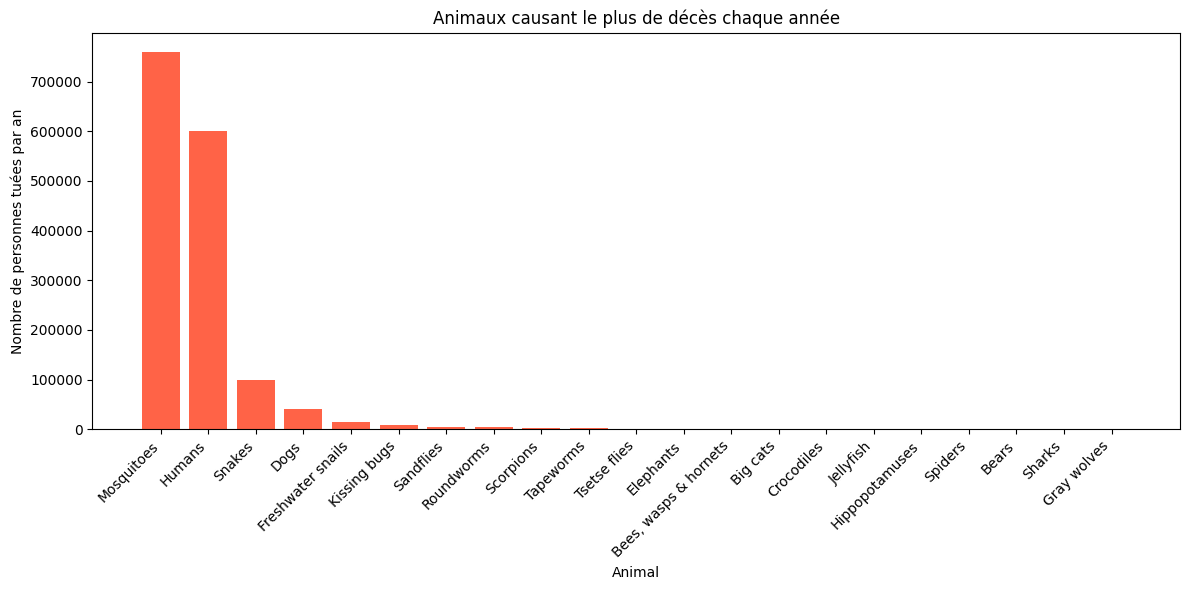

In [6]:
df["Number of humans killed per year"] = pd.to_numeric(
    df["Number of humans killed per year"],
    errors="coerce"
)

df = df.dropna(subset=["Animal", "Number of humans killed per year"])
df = df.sort_values("Number of humans killed per year", ascending=False)

plt.figure(figsize=(12, 6))

plt.bar(
    df["Animal"],
    df["Number of humans killed per year"],
    color="tomato"
)

plt.xlabel("Animal")
plt.ylabel("Nombre de personnes tuées par an")
plt.title("Animaux causant le plus de décès chaque année")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

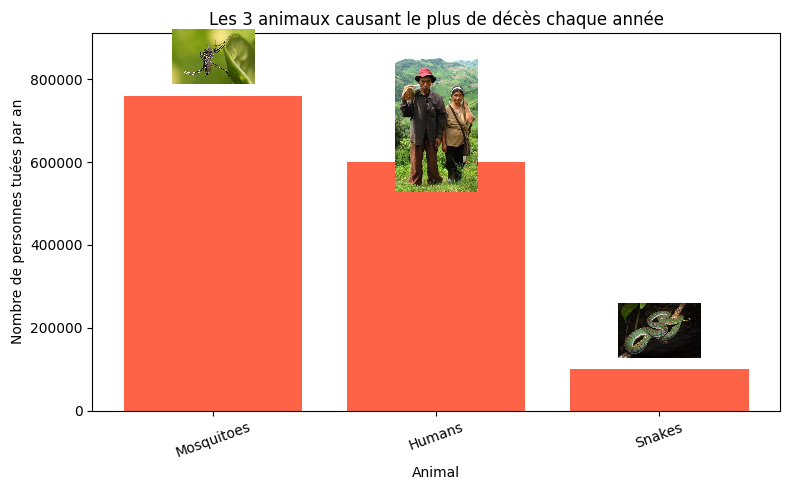

In [11]:
import json
from io import BytesIO
from urllib.error import URLError
from urllib.parse import quote
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

df = df.head(3)
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    df["Animal"],
    df["Number of humans killed per year"],
    color="tomato"
)

for bar, (_, animal) in zip(bars, df.iterrows()):
    try:
        page_url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{quote(animal['Animal'].replace(' ', '_'), safe='')}"
        page_request = Request(page_url, headers={"User-Agent": "DeadliestAnimalsNotebook/1.0"})
        with urlopen(page_request, timeout=5) as response:
            image_url = json.load(response).get("thumbnail", {}).get("source")
        if image_url:
            image_request = Request(image_url, headers={"User-Agent": "DeadliestAnimalsNotebook/1.0"})
            with urlopen(image_request, timeout=5) as response:
                image = Image.open(BytesIO(response.read())).convert("RGBA")
            marker = AnnotationBbox(
                OffsetImage(image, zoom=0.18),
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xybox=(0, 28),
                boxcoords="offset points",
                frameon=False
            )
            ax.add_artist(marker)
    except (URLError, TimeoutError, json.JSONDecodeError, OSError):
        pass

ax.set_ylim(0, df["Number of humans killed per year"].max() * 1.2)
ax.set_xlabel("Animal")
ax.set_ylabel("Nombre de personnes tuées par an")
ax.set_title("Les 3 animaux causant le plus de décès chaque année")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()